# Data Visualization
El siguiente cuaderno presenta distintos métodos de visualización aplicados al conjunto de datos **NSL-KDD**, una versión mejorada de KDD’99 diseñada para evaluar sistemas de detección de intrusos (IDS) en tráfico de red.  

De forma general, NSL-KDD contiene registros de conexiones etiquetadas como **tráfico normal** o **tipos de ataque**, por lo que es útil como conjunto de referencia para tareas de clasificación, análisis exploratorio y comparación de modelos.

Aunque no representa por completo las redes reales actuales, NSL-KDD sigue siendo ampliamente utilizado en investigación por su estructura, tamaño manejable y etiquetas estandarizadas.

### Fuente del dataset
El siguiente dataset puede descargarse en este enlace: **https://www.kaggle.com/datasets/hassan06/nslkdd**.  
Está disponible en formatos **TXT** y **ARFF**.

### Archivos principales
- **KDDTrain+.ARFF**: conjunto de entrenamiento completo con etiquetas binarias (formato ARFF).
- **KDDTrain+.TXT**: conjunto de entrenamiento completo con tipo de ataque y nivel de dificultad (formato TXT/CSV).
- **KDDTrain+_20Percent.ARFF**: subconjunto del 20% del entrenamiento en ARFF.
- **KDDTrain+_20Percent.TXT**: subconjunto del 20% del entrenamiento en TXT/CSV.
- **KDDTest+.ARFF**: conjunto de prueba completo con etiquetas binarias (ARFF).
- **KDDTest+.TXT**: conjunto de prueba completo con tipo de ataque y dificultad (TXT/CSV).
- **KDDTest-21.ARFF**: subconjunto de prueba sin registros con dificultad 21.
- **KDDTest-21.TXT**: subconjunto de prueba sin registros con dificultad 21.


## 1. Importación de librerías

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from pandas.plotting import scatter_matrix

%matplotlib inline

# 2. Lectura de datos

In [19]:
# Cargar datos del dataset NSL-KDD, asignar nombres de columnas y convertir de TXT a CSV

COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "class", "difficulty"
]

train_df = pd.read_csv("data/KDDTrain+.txt", header=None, names=COLUMN_NAMES)
test_df = pd.read_csv("data/KDDTest+.txt", header=None, names=COLUMN_NAMES)

train_df.to_csv("data/KDDTrain+.csv", index=False)
test_df.to_csv("data/KDDTest+.csv", index=False)

## 3. Funciones básicas de visualización de los datos


In [20]:
# Consultar los primeros registros para verificar que se cargaron correctamente
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [21]:
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [22]:
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (125973, 43)
Test set shape: (22544, 43)


In [23]:
# Consultar los tipos de datos
train_df.dtypes

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [24]:
# Mostrar información general del dataset

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [25]:
# Mostrar información estadística sobre el conjunto de datos
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [26]:
# Mostrar los valores únicos que tiene un atributo determinado
train_df["protocol_type"].value_counts()

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

In [27]:
# Mostrar la distribución de la clase objetivo
train_df["class"].value_counts()

class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

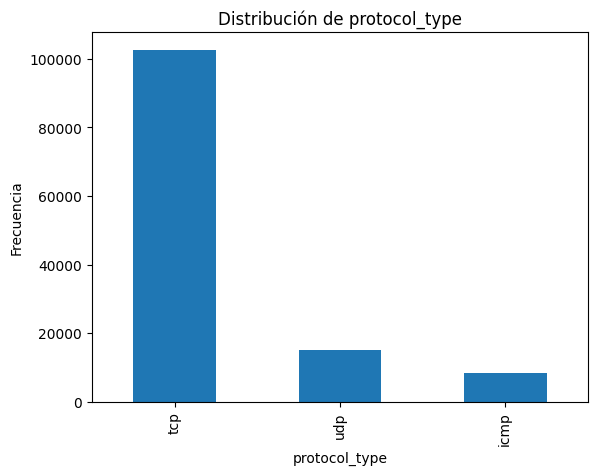

In [28]:
# Representación gráfica de una característica categórica
train_df["protocol_type"].value_counts().plot(kind="bar")
plt.title("Distribución de protocol_type")
plt.xlabel("protocol_type")
plt.ylabel("Frecuencia")
plt.show()

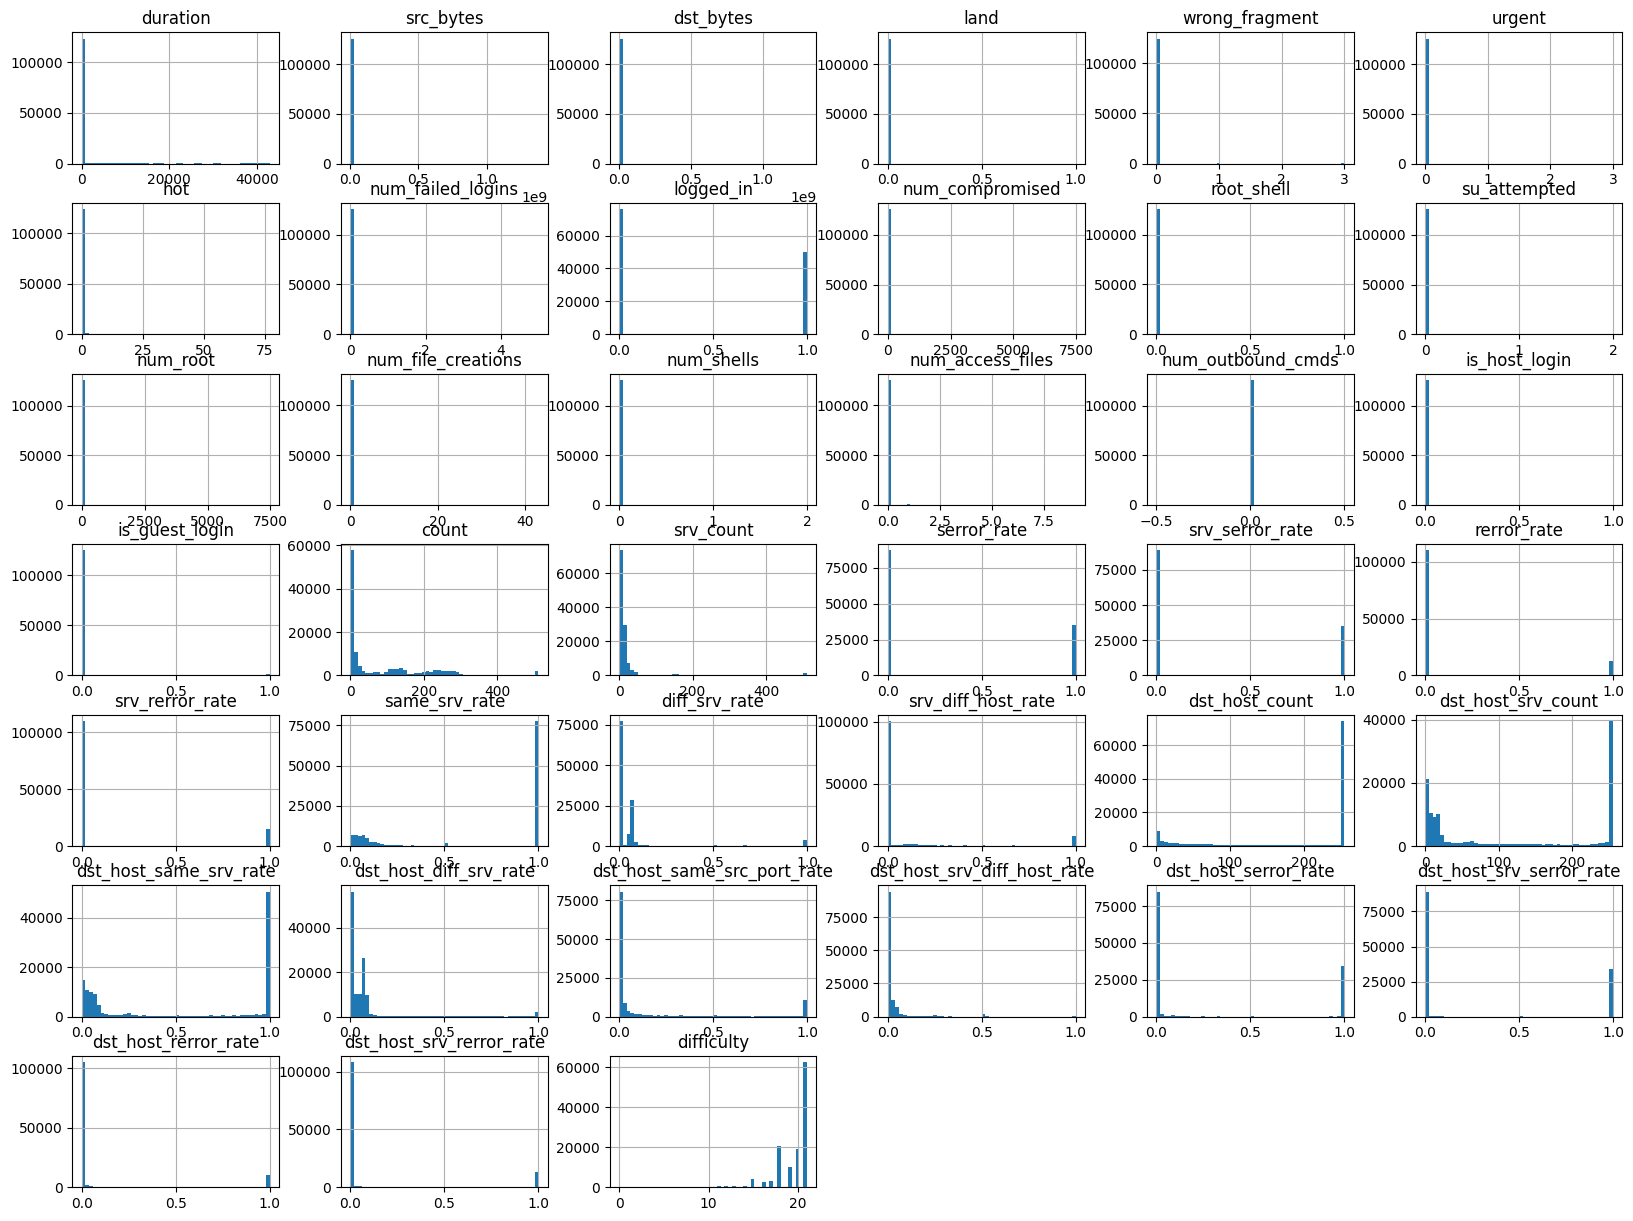

In [29]:
# Representar gráficamente la distribución de los atributos
train_df.hist(bins=50, figsize=(20,15))
plt.show()

# 3. Funciones avanzadas de visualización de los datos

* Se puede calcular el coeficiente de correlación estándar para ver la correlación entre cada par de atributos.
* El coeficiente de correlación solo mide **correlaciones lineales**.
* Para calcular correlaciones, primero hay que convertir a valores numéricos la variable objetivo `class` y los atributos categóricos.

In [30]:
# El atributo class tiene valores categoricos
train_df["class"]


0          normal
1          normal
2         neptune
3          normal
4          normal
           ...   
125968    neptune
125969     normal
125970     normal
125971    neptune
125972     normal
Name: class, Length: 125973, dtype: object

In [33]:
# Convierte valores categóricos de la columnas a numéricos (números enteros) utilizando LabelEncoder
df = train_df.copy()  # Crear una copia del DataFrame original para evitar modificarlo directamente
labelencoder = LabelEncoder()
df["class"] = labelencoder.fit_transform(df["class"])
df["protocol_type"] = labelencoder.fit_transform(df["protocol_type"])
df["service"] = labelencoder.fit_transform(df["service"])
df["flag"] = labelencoder.fit_transform(df["flag"])

df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,11,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,11,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9,19
3,0,1,24,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,11,21
4,0,1,24,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,9,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,11,21
125970,0,1,54,9,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,11,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9,20


In [41]:
# Value counts por cada columna seleccionada
columnas = ["class", "protocol_type", "service", "flag"]

for col in columnas:
    print(f"\n=== {col} (conteo) ===")
    print(df[col].value_counts())
    print(f"\n=== {col} (porcentaje) ===")
    print((df[col].value_counts(normalize=True) * 100).round(2))


=== class (conteo) ===
class
11    67343
9     41214
17     3633
5      3599
15     2931
18     2646
10     1493
0       956
20      892
21      890
14      201
3        53
1        30
22       20
6        18
4        11
16       10
7         9
2         8
8         7
13        4
12        3
19        2
Name: count, dtype: int64

=== class (porcentaje) ===
class
11    53.46
9     32.72
17     2.88
5      2.86
15     2.33
18     2.10
10     1.19
0      0.76
20     0.71
21     0.71
14     0.16
3      0.04
1      0.02
22     0.02
6      0.01
4      0.01
16     0.01
7      0.01
2      0.01
8      0.01
13     0.00
12     0.00
19     0.00
Name: proportion, dtype: float64

=== protocol_type (conteo) ===
protocol_type
1    102689
2     14993
0      8291
Name: count, dtype: int64

=== protocol_type (porcentaje) ===
protocol_type
1    81.52
2    11.90
0     6.58
Name: proportion, dtype: float64

=== service (conteo) ===
service
24    40338
49    21853
12     9043
54     7313
20     6860
      .

In [ ]:
# Matriz de correlación para identificar relaciones entre atributos numéricos

corr_matrix = df.corr()
corr_matrix["class"].sort_values(ascending=False)

class                          1.000000
srv_count                      0.310819
wrong_fragment                 0.304125
dst_host_diff_srv_rate         0.295042
same_srv_rate                  0.258357
diff_srv_rate                  0.228557
dst_host_same_src_port_rate    0.202229
flag                           0.170749
dst_host_srv_count             0.138848
protocol_type                  0.135203
duration                       0.134590
is_guest_login                 0.109112
dst_host_rerror_rate           0.108057
dst_host_srv_rerror_rate       0.106217
logged_in                      0.104056
rerror_rate                    0.099397
hot                            0.098611
srv_rerror_rate                0.098105
dst_host_same_srv_rate         0.073548
count                          0.060380
dst_host_count                 0.053869
src_bytes                      0.011617
dst_bytes                      0.007600
num_access_files               0.005220
su_attempted                   0.004005


In [43]:
# Mostrar correlación lineal entre todos los atributos del conjunto de datos
df.corr()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
duration,1.000000,0.038241,0.092858,-0.063390,0.070737,0.034878,-0.001553,-0.009866,0.003830,0.000705,...,-0.116005,0.254195,0.228737,-0.026669,-0.064948,-0.064361,0.173815,0.199024,0.134590,-0.156311
protocol_type,0.038241,1.000000,0.029994,0.093668,-0.000974,-0.000608,-0.001757,0.169535,-0.000965,-0.011857,...,0.001702,0.131380,-0.209105,-0.356183,-0.079398,-0.077925,-0.015434,-0.046938,0.135203,0.082775
service,0.092858,0.029994,1.000000,-0.304014,-0.001631,0.003596,-0.009952,0.084404,0.010980,-0.064066,...,-0.452696,0.284072,-0.111163,-0.156211,0.281635,0.277594,0.150666,0.148405,-0.001798,0.033724
flag,-0.063390,0.093668,-0.304014,1.000000,-0.008114,-0.004096,-0.010373,0.067214,0.005811,0.068437,...,0.630118,-0.283607,0.195689,0.073773,-0.443441,-0.443225,-0.683310,-0.718778,0.170749,0.054179
src_bytes,0.070737,-0.000974,-0.001631,-0.008114,1.000000,0.000204,-0.000109,-0.000693,-0.000059,0.000295,...,-0.006572,0.000900,0.000431,-0.001655,-0.004503,-0.003397,-0.001468,0.012449,0.011617,-0.022592
dst_bytes,0.034878,-0.000608,0.003596,-0.004096,0.000204,1.000000,-0.000069,-0.000440,0.000248,-0.000344,...,-0.004424,0.011031,0.011747,-0.001281,-0.003024,-0.002944,0.011729,0.011223,0.007600,-0.018076
land,-0.001553,-0.001757,-0.009952,-0.010373,-0.000109,-0.000069,1.000000,-0.001261,-0.000109,-0.001340,...,0.011597,-0.004516,0.033851,0.070474,0.019840,0.012276,-0.005222,-0.005303,-0.017239,-0.037038
wrong_fragment,-0.009866,0.169535,0.084404,0.067214,-0.000693,-0.000440,-0.001261,1.000000,-0.000692,-0.008508,...,-0.048733,0.059797,0.037177,-0.016252,-0.051917,-0.055917,0.028890,-0.033682,0.304125,-0.157130
urgent,0.003830,-0.000965,0.010980,0.005811,-0.000059,0.000248,-0.000109,-0.000692,1.000000,0.000293,...,-0.004489,0.006840,0.002741,0.005176,-0.004749,-0.004834,-0.002999,-0.002912,-0.003513,-0.016411
hot,0.000705,-0.011857,-0.064066,0.068437,0.000295,-0.000344,-0.001340,-0.008508,0.000293,1.000000,...,-0.036293,-0.012293,-0.034536,-0.024715,-0.058222,-0.058214,-0.030555,-0.031670,0.098611,-0.160013


La matriz de correlación muestra que varias métricas de error y de comportamiento de conexión tienen relación lineal con la variable `class`, por lo que son útiles para discriminar entre tráfico normal y ataques.  
También hay atributos fuertemente correlacionados entre sí, lo que sugiere posible redundancia y la conveniencia de aplicar selección de variables.

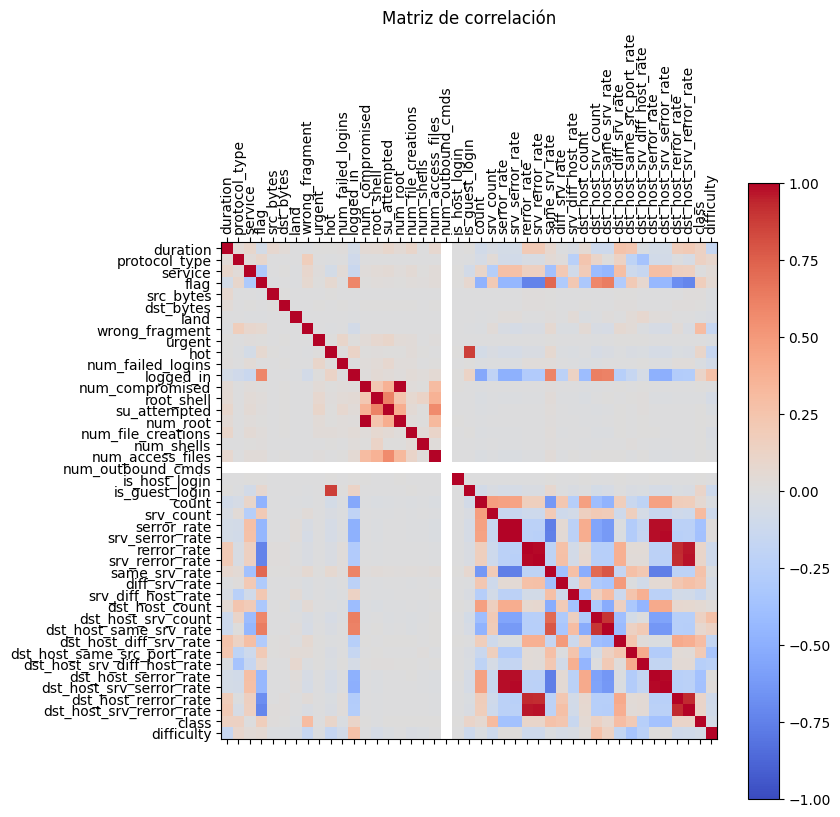

In [ ]:
# Representar gráficamente la matriz de correlación a través de un heatmap
corr = df.corr()
fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90);
plt.yticks(range(len(corr.columns)), corr.columns);
plt.title("Matriz de correlación")
plt.show()

El conjunto presenta grupos de variables con comportamiento muy similar, en especial entre métricas de error y de rechazo. Estas correlaciones altas indican que varias características aportan información relacionada y pueden estar describiendo un mismo patrón de tráfico.

También se observa que `class` tiene asociación con un subconjunto de atributos de red, lo que respalda que la separación entre tráfico normal y ataques puede modelarse a partir de estas señales. En términos prácticos, esto sugiere que el dataset contiene estructura útil para tareas de clasificación supervisada.

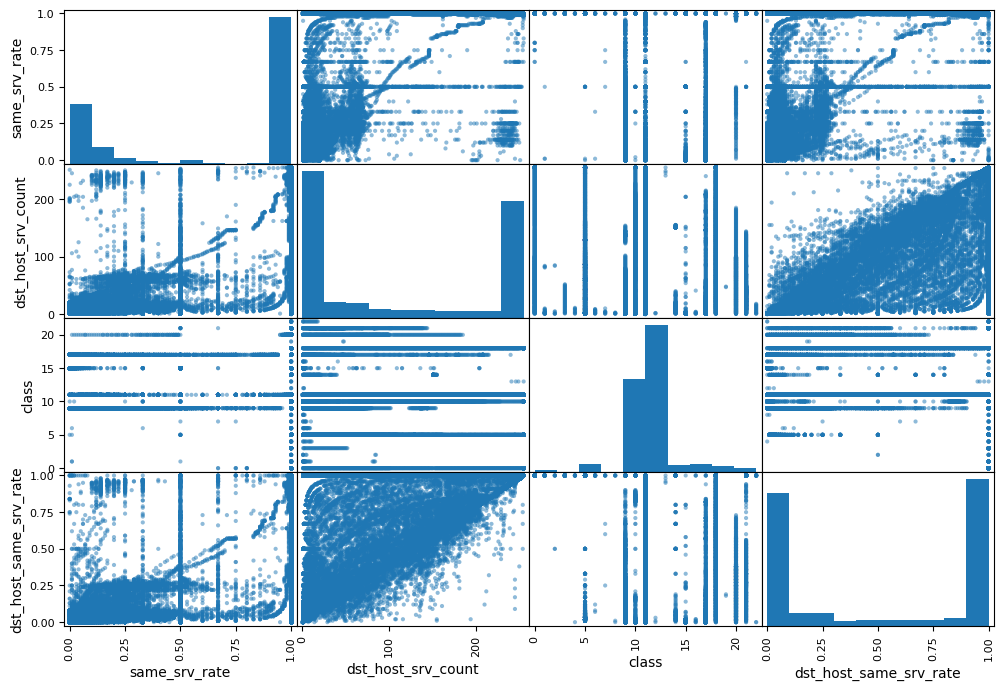

In [48]:
# Matriz de dispersión para visualizar relaciones entre atributos numéricos
attributes = ["same_srv_rate", "dst_host_srv_count", "class", "dst_host_same_srv_rate"]

scatter_matrix(df[attributes], figsize=(12,8))
plt.show()

En la matriz de dispersión se aprecia una relación positiva entre `dst_host_srv_count` y `dst_host_same_srv_rate`, lo que sugiere que cuando aumenta el número de servicios del host destino también crece su tasa de servicio similar.

La variable `class` aparece en bandas discretas y con solapamientos frente a los demás atributos, indicando que un solo predictor no separa completamente las clases y que la combinación de variables será más útil para clasificar tráfico normal y ataques.

In [ ]:
# Mostrar la correlación lineal entre cada atributo y la clase objetivo, del más correlacionado al menos correlacionado 
df.corr()["class"].sort_values(ascending=False)

class                          1.000000
srv_count                      0.310819
wrong_fragment                 0.304125
dst_host_diff_srv_rate         0.295042
same_srv_rate                  0.258357
diff_srv_rate                  0.228557
dst_host_same_src_port_rate    0.202229
flag                           0.170749
dst_host_srv_count             0.138848
protocol_type                  0.135203
duration                       0.134590
is_guest_login                 0.109112
dst_host_rerror_rate           0.108057
dst_host_srv_rerror_rate       0.106217
logged_in                      0.104056
rerror_rate                    0.099397
hot                            0.098611
srv_rerror_rate                0.098105
dst_host_same_srv_rate         0.073548
count                          0.060380
dst_host_count                 0.053869
src_bytes                      0.011617
dst_bytes                      0.007600
num_access_files               0.005220
su_attempted                   0.004005


In [51]:
# Exportar el DataFrame a un nuevo archivo CSV
df.to_csv("data/KDDTrain_processed.csv", index=False)